# NST(photo)

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import vgg19

In [7]:
RESIZE_HEIGHT = 607
NUM_ITER = 1000
CONTENT_WEIGHT = 8e-4
STYLE_WEIGHT = 8e-1
CONTENT_LAYER_NAME = "block5_conv2"
STYLE_LAYER_NAMES = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",
]


In [3]:
def get_result_image_size(image_path, result_height):
    image_width, image_height = keras.preprocessing.image.load_img(image_path).size
    result_width = int(image_width * result_height / image_height)
    return result_height, result_width

In [4]:
def preprocess_image(image_path, target_height, target_width):
    img = keras.preprocessing.image.load_img(image_path, target_size=(target_height, target_width))
    arr = keras.preprocessing.image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = vgg19.preprocess_input(arr)
    return tf.convert_to_tensor(arr)

In [5]:
def get_model():
    model = vgg19.VGG19(weights='imagenet', include_top=False)
    outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])
    return keras.Model(inputs=model.inputs, outputs=outputs_dict)

def get_optimizer():
    return keras.optimizers.Adam(
        keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=8.0, decay_steps=445, decay_rate=0.98
        )
    )

def compute_loss(feature_extractor, combination_image, content_features, style_features):
    combination_features = feature_extractor(combination_image)
    loss_content = compute_content_loss(content_features, combination_features)
    loss_style = compute_style_loss(style_features, combination_features, combination_image.shape[1] * combination_image.shape[2])
    return CONTENT_WEIGHT * loss_content + STYLE_WEIGHT * loss_style

def compute_content_loss(content_features, combination_features):
    original_image = content_features[CONTENT_LAYER_NAME]
    generated_image = combination_features[CONTENT_LAYER_NAME]
    return tf.reduce_sum(tf.square(generated_image - original_image)) / 2

def compute_style_loss(style_features, combination_features, combination_size):
    loss_style = 0
    for layer_name in STYLE_LAYER_NAMES:
        style_feature = style_features[layer_name][0]
        combination_feature = combination_features[layer_name][0]
        loss_style += style_loss(style_feature, combination_feature, combination_size) / len(STYLE_LAYER_NAMES)
    return loss_style

def style_loss(style_features, combination_features, combination_size):
    S = gram_matrix(style_features)
    C = gram_matrix(combination_features)
    channels = style_features.shape[2]
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (combination_size ** 2))

def gram_matrix(x):
    x = tf.transpose(x, (2, 0, 1))
    features = tf.reshape(x, (tf.shape(x)[0], -1))
    gram = tf.matmul(features, tf.transpose(features))
    return gram

def save_result(generated_image, result_height, result_width, name):
    img = deprocess_image(generated_image, result_height, result_width)
    keras.preprocessing.image.save_img(name, img)

def deprocess_image(tensor, result_height, result_width):
    tensor = tensor.numpy()
    tensor = tensor.reshape((result_height, result_width, 3))
    tensor[:, :, 0] += 103.939
    tensor[:, :, 1] += 116.779
    tensor[:, :, 2] += 123.680
    tensor = tensor[:, :, ::-1]
    return np.clip(tensor, 0, 255).astype("uint8")

In [ ]:
def style_transfer_pipeline(content_image_path, style_image_path):

    result_height, result_width = get_result_image_size(content_image_path, RESIZE_HEIGHT)
    print("result resolution: (%d, %d)" % (result_height, result_width))

    content_tensor = preprocess_image(content_image_path, result_height, result_width)
    style_tensor = preprocess_image(style_image_path, result_height, result_width)
    generated_image = tf.Variable(tf.random.uniform(style_tensor.shape, dtype=tf.dtypes.float32))

    model = get_model()
    optimizer = get_optimizer()
    print(model.summary())

    content_features = model(content_tensor)
    style_features = model(style_tensor)

    for iter in range(NUM_ITER):
        with tf.GradientTape() as tape:
            loss = compute_loss(model, generated_image, content_features, style_features)

        grads = tape.gradient(loss, generated_image)

        print("iter: %4d, loss: %8.f" % (iter, loss))
        optimizer.apply_gradients([(grads, generated_image)])

        if (iter + 1) % 100 == 0:
            name = "result/generated_at_iteration_%d.png" % (iter + 1)
            save_result(generated_image, result_height, result_width, name)

    name = "result/result_%d_%f_%f.png" % (NUM_ITER, CONTENT_WEIGHT, STYLE_WEIGHT)
    save_result(generated_image, result_height, result_width, name)

if __name__ == "__main__":

    path = os.path.abspath(os.getcwd())
    content_image_path = os.path.join(path, 'bob.png')
    style_image_path = os.path.join(path, 'hell.jpg')
    style_transfer_pipeline(content_image_path, style_image_path)

# Results

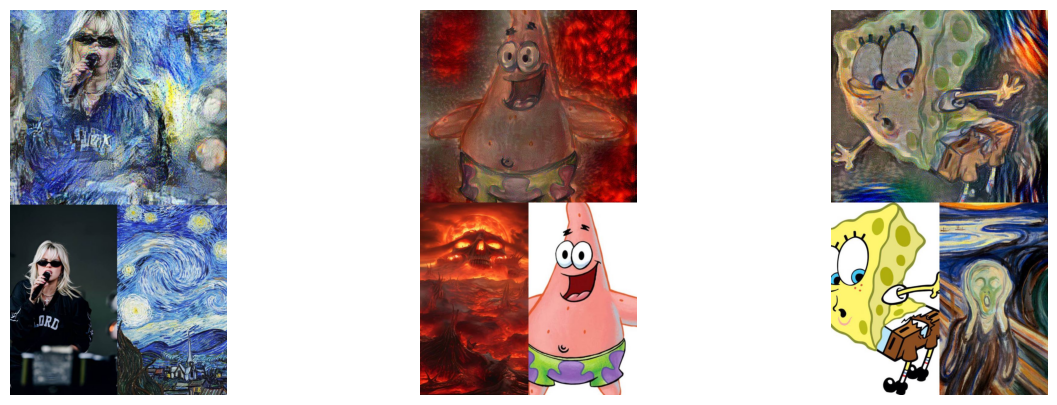

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image1 = mpimg.imread('rene.jpg')
image2 = mpimg.imread('patr.jpg')
image3 = mpimg.imread('bob.jpg')
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  
axs[0].imshow(image1)
axs[0].axis('off') 
axs[1].imshow(image2)
axs[1].axis('off') 
axs[2].imshow(image3)
axs[2].axis('off') 
plt.show()


# Video

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import vgg19

RESIZE_HEIGHT = 607
NUM_ITER = 100  
CONTENT_WEIGHT = 8e-4
STYLE_WEIGHT = 8e-1
CONTENT_LAYER_NAME = "block5_conv2"
STYLE_LAYER_NAMES = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",
]

def get_result_image_size(image_shape, result_height):
    image_height, image_width = image_shape
    result_width = int(image_width * result_height / image_height)
    return result_height, result_width

def preprocess_image(image, target_height, target_width):
    img = cv2.resize(image, (target_width, target_height))
    arr = keras.preprocessing.image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = vgg19.preprocess_input(arr)
    return tf.convert_to_tensor(arr)

def get_model():
    model = vgg19.VGG19(weights='imagenet', include_top=False)
    outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])
    return keras.Model(inputs=model.inputs, outputs=outputs_dict)

def get_optimizer():
    return keras.optimizers.Adam(
        keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=8.0, decay_steps=445, decay_rate=0.98
        )
    )

def compute_loss(feature_extractor, combination_image, content_features, style_features):
    combination_features = feature_extractor(combination_image)
    loss_content = compute_content_loss(content_features, combination_features)
    loss_style = compute_style_loss(style_features, combination_features, combination_image.shape[1] * combination_image.shape[2])
    return CONTENT_WEIGHT * loss_content + STYLE_WEIGHT * loss_style

def compute_content_loss(content_features, combination_features):
    original_image = content_features[CONTENT_LAYER_NAME]
    generated_image = combination_features[CONTENT_LAYER_NAME]
    return tf.reduce_sum(tf.square(generated_image - original_image)) / 2

def compute_style_loss(style_features, combination_features, combination_size):
    loss_style = 0
    for layer_name in STYLE_LAYER_NAMES:
        style_feature = style_features[layer_name][0]
        combination_feature = combination_features[layer_name][0]
        loss_style += style_loss(style_feature, combination_feature, combination_size) / len(STYLE_LAYER_NAMES)
    return loss_style

def style_loss(style_features, combination_features, combination_size):
    S = gram_matrix(style_features)
    C = gram_matrix(combination_features)
    channels = style_features.shape[2]
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (combination_size ** 2))

def gram_matrix(x):
    x = tf.transpose(x, (2, 0, 1))
    features = tf.reshape(x, (tf.shape(x)[0], -1))
    gram = tf.matmul(features, tf.transpose(features))
    return gram

def deprocess_image(tensor, result_height, result_width):
    tensor = tensor.numpy()
    tensor = tensor.reshape((result_height, result_width, 3))
    tensor[:, :, 0] += 103.939
    tensor[:, :, 1] += 116.779
    tensor[:, :, 2] += 123.680
    tensor = tensor[:, :, ::-1]
    return np.clip(tensor, 0, 255).astype("uint8")

def style_transfer_on_frame(frame, model, content_features, style_features, optimizer, result_height, result_width):
    frame_tensor = preprocess_image(frame, result_height, result_width)
    generated_image = tf.Variable(tf.random.uniform(frame_tensor.shape, dtype=tf.dtypes.float32))
    for _ in range(NUM_ITER):
        with tf.GradientTape() as tape:
            loss = compute_loss(model, generated_image, content_features, style_features)
        grads = tape.gradient(loss, generated_image)
        optimizer.apply_gradients([(grads, generated_image)])
    return deprocess_image(generated_image, result_height, result_width)

def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames

def save_video(frames, output_path, fps):
    height, width, _ = frames[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for saving the video
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    for frame in frames:
        out.write(frame)
    out.release()

def style_transfer_pipeline(content_video_path, style_image_path, output_video_path):
 
    frames = extract_frames(content_video_path)
    frame_height, frame_width = frames[0].shape[:2]
    result_height, result_width = get_result_image_size((frame_height, frame_width), RESIZE_HEIGHT)
    print("result resolution: (%d, %d)" % (result_height, result_width))

    style_image = cv2.imread(style_image_path)
    style_tensor = preprocess_image(style_image, result_height, result_width)

    model = get_model()
    optimizer = get_optimizer()
    print(model.summary())

    style_features = model(style_tensor)

    styled_frames = []
    for i, frame in enumerate(frames):
        print(f"Processing frame {i + 1}/{len(frames)}")
        
        content_tensor = preprocess_image(frame, result_height, result_width)
        content_features = model(content_tensor)
 
        styled_frame = style_transfer_on_frame(frame, model, content_features, style_features, optimizer, result_height, result_width)
        styled_frames.append(styled_frame)

    cap = cv2.VideoCapture(content_video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)  # Get frames per second from original video
    cap.release()
    save_video(styled_frames, output_video_path, fps)
    print(f"Styled video saved to {output_video_path}")

if __name__ == "__main__":
    path = os.path.abspath(os.getcwd())
    content_video_path = os.path.join(path, 'IMG_8867.MOV')  
    style_image_path = os.path.join(path, 'hell.jpg')  
    output_video_path = os.path.join(path, 'styled_video.mp4') 

    style_transfer_pipeline(content_video_path, style_image_path, output_video_path)


[NULL @ 0x562320733a00] Invalid NAL unit size (-310484168 > 9909).
[NULL @ 0x562320733a00] missing picture in access unit with size 9913
[h264 @ 0x56231fb44200] Invalid NAL unit size (-310484168 > 9909).
[h264 @ 0x56231fb44200] Error splitting the input into NAL units.
[NULL @ 0x562320733a00] Invalid NAL unit size (1550939641 > 11184).
[NULL @ 0x562320733a00] missing picture in access unit with size 11188
[h264 @ 0x562320915580] Invalid NAL unit size (1550939641 > 11184).
[h264 @ 0x562320915580] Error splitting the input into NAL units.
[NULL @ 0x562320733a00] Invalid NAL unit size (936476864 > 5906).
[NULL @ 0x562320733a00] missing picture in access unit with size 5910
[h264 @ 0x56231fd32780] Invalid NAL unit size (936476864 > 5906).
[h264 @ 0x56231fd32780] Error splitting the input into NAL units.
[NULL @ 0x562320733a00] Invalid NAL unit size (1522813707 > 7229).
[NULL @ 0x562320733a00] missing picture in access unit with size 7233
[h264 @ 0x5623200df3c0] Invalid NAL unit size (15228

result resolution: (607, 607)
Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  